# 02 · Un proceso gaussiano paso a paso: desde cero, con scikit-learn, y con dos kernels

**Pregunta de la clase.** Una ciudad pequeña registra su demanda eléctrica diaria (MW). Tenemos 4 semanas de datos, con un hueco
de 3 días en que falló el medidor. **¿Cuánta capacidad debemos reservar para la próxima semana?**

Para responder no basta una curva: necesitamos la curva **y su margen de error**. Eso es lo que da un proceso gaussiano (GP).

Plan:

| Paso | Qué hacemos | Idea que se lleva |
|---|---|---|
| 0 | Los datos y la pregunta | Escondemos el futuro para poder destaparlo |
| 1 | El kernel | Nuestra única hipótesis: qué tan parecidos son dos días |
| 2 | El GP antes de ver datos | Con la hipótesis se sortean curvas posibles |
| 3 | El GP después de ver datos, **línea por línea** | Seis líneas de álgebra actualizan la hipótesis |
| 4 | La respuesta | El margen es la respuesta |
| 5 | Lo mismo con scikit-learn | Tres líneas; resultado idéntico |
| 6 | **Sumar dos kernels** | Sumar hipótesis: suave + repetitivo |

> Los nombres de las variables (`kxx`, `kXX`, `B1`…`B4`, `R`, `A`, `mpost`, `vpost`, `spost`, `stdpo`) son los mismos del código
> MATLAB que vimos en la presentación, para leerlos lado a lado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
AZUL, ORO, GRIS = "#003D79", "#D59F0F", "#8A8F98"   # colores UNAM
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

## Paso 0 · Los datos y la pregunta

Datos **sintéticos** (generados con una fórmula): así todos tenemos la misma serie y podemos esconder el futuro y luego destaparlo.
La serie imita a una ciudad que entra en una ola de calor. Tiene tres ingredientes, y conviene verlos por separado porque en el Paso 6 volveremos a ellos:

1. una **tendencia** que sube de ~120 a ~145 MW a lo largo del mes,
2. un **vaivén** suave que se repite cada 14 días (±5 MW),
3. **ruido** de medición (±2.5 MW).

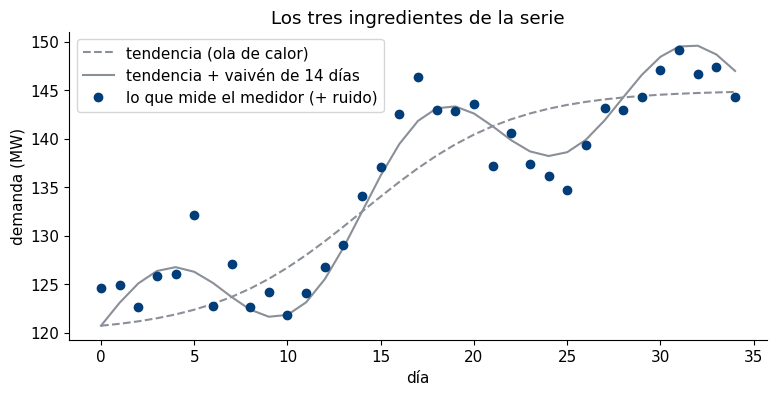

In [2]:
def demanda_ciudad(dias=35, semilla=30):
    rng = np.random.default_rng(semilla)
    t = np.arange(dias, dtype=float)                       # día 0, 1, 2, ...
    tendencia = 120 + 25 / (1 + np.exp(-(t - 14) / 4))    # ola de calor: sube 25 MW a media serie
    vaiven    = 5 * np.sin(2 * np.pi * t / 14)             # oscilación de ±5 MW que se repite cada 14 días
    ruido     = rng.normal(0, 2.5, dias)                   # error de medición
    return t, tendencia + vaiven + ruido, tendencia, vaiven

t, y, tendencia, vaiven = demanda_ciudad()

plt.plot(t, tendencia, color=GRIS, ls="--", label="tendencia (ola de calor)")
plt.plot(t, tendencia + vaiven, color=GRIS, label="tendencia + vaivén de 14 días")
plt.plot(t, y, "o", color=AZUL, label="lo que mide el medidor (+ ruido)")
plt.xlabel("día"); plt.ylabel("demanda (MW)"); plt.legend(loc="upper left"); plt.title("Los tres ingredientes de la serie")
plt.show()

Ahora escondemos lo que **no** sabríamos en la vida real: la próxima semana (días 28 a 34) y tres días en que el medidor falló (12, 13, 14).

25 días observados, 10 sin dato


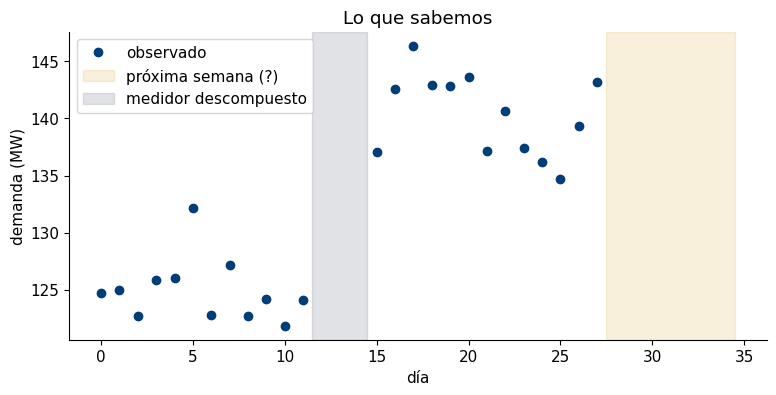

In [3]:
observado = np.ones(len(t), dtype=bool)
observado[28:] = False          # días 28..34 = la próxima semana (no la conocemos)
observado[12:15] = False        # días 12, 13, 14 = falla del medidor

X, Y = t[observado], y[observado]      # mayúsculas: los DATOS (como en el código MATLAB)
print(f"{len(X)} días observados, {(~observado).sum()} sin dato")

plt.plot(X, Y, "o", color=AZUL, label="observado")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15, label="próxima semana (?)")
plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25, label="medidor descompuesto")
plt.xlabel("día"); plt.ylabel("demanda (MW)"); plt.legend(loc="upper left"); plt.title("Lo que sabemos")
plt.show()

**La apuesta.** Antes de hacer cuentas: a ojo, ¿cuánta capacidad reservarías para la próxima semana? Anota un número y un rango en papel. Al final los comparamos.

## Paso 1 · El kernel: ¿cuánto se parecen dos días?

Un GP no supone una fórmula para la curva (no dice "es una recta" ni "es una parábola"). Supone algo más humilde:
**qué tan parecidos son los valores de dos días según qué tan lejos están**. Esa regla es el **kernel**.

Hoy empezamos con el más usado, el RBF (*radial basis function*, también llamado exponencial cuadrado):

$$k(t, t') = \sigma_f^2 \, \exp\!\left(-\frac{(t-t')^2}{2\ell^2}\right)$$

Tiene dos números, y hay un tercero fuera del kernel:

| Símbolo | Nombre | Qué controla | Valor de hoy |
|---|---|---|---|
| $\ell$ | *length scale* | a cuántos días de distancia dos demandas dejan de parecerse | 5 días |
| $\sigma_f$ | amplitud | cuánto puede subir o bajar la curva alrededor de su media | la desviación estándar de los datos |
| $\sigma_n$ | ruido | cuánto error trae cada medición | 2.5 MW |

Estos tres son los **hiperparámetros**. Primero los fijamos a mano; en el Paso 5 scikit-learn los aprenderá solo.

In [4]:
ell     = 5.0        # días
sigma_f = Y.std()    # MW
sigma_n = 2.5        # MW
b       = Y.mean()   # media a priori: sin datos, apostamos al promedio (en MATLAB: b = mean(Y))

def k(a, c):
    # Kernel RBF entre todos los pares de días de `a` y de `c`. Devuelve una matriz len(a) x len(c).
    return sigma_f**2 * np.exp(-0.5 * (a[:, None] - c[None, :])**2 / ell**2)

print(f"σ_f = {sigma_f:.1f} MW,  ℓ = {ell:.0f} días,  σ_n = {sigma_n:.1f} MW,  b = {b:.1f} MW")

σ_f = 8.3 MW,  ℓ = 5 días,  σ_n = 2.5 MW,  b = 132.9 MW


### 1a · Qué hace ℓ

La curva del kernel es el parecido entre el día 10 y cualquier otro día. Con ℓ chica el parecido se pierde en dos días; con ℓ grande dura semanas.

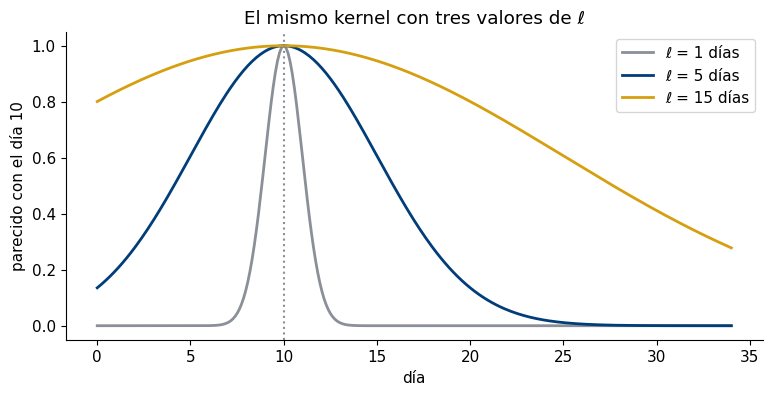

In [5]:
d = np.linspace(0, 34, 300)
for ell_prueba, color in [(1.0, GRIS), (5.0, AZUL), (15.0, ORO)]:
    parecido = np.exp(-0.5 * (10 - d)**2 / ell_prueba**2)        # el kernel sin σ_f², para comparar formas
    plt.plot(d, parecido, color=color, lw=2, label=f"ℓ = {ell_prueba:.0f} días")
plt.axvline(10, color=GRIS, ls=":")
plt.xlabel("día"); plt.ylabel("parecido con el día 10"); plt.legend(); plt.title("El mismo kernel con tres valores de ℓ")
plt.show()

### 1b · La matriz de parecidos

El kernel se evalúa para **todos los pares** de días observados a la vez: sale una matriz de 25 × 25 (25 días observados).
Cada casilla (i, j) dice cuánto se parecen los días i y j. Nótese el hueco del medidor: los días a ambos lados se parecen menos entre sí porque están más lejos.

forma de kXX: (25, 25)
kXX[0, 0] = 68.5  (un día consigo mismo: σ_f²)
kXX[0, 1] = 67.2  (día 0 con día 1)
kXX[0, 10]= 9.3  (día 0 con día 10)


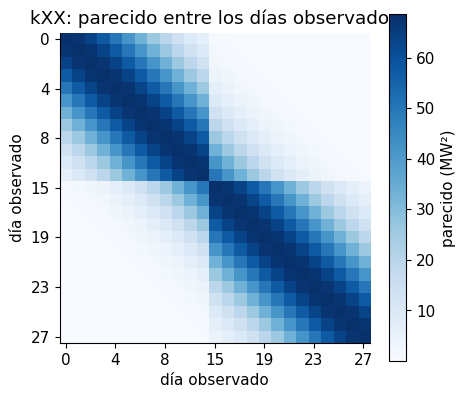

In [6]:
kXX = k(X, X)
print("forma de kXX:", kXX.shape)
print("kXX[0, 0] =", round(kXX[0, 0], 1), " (un día consigo mismo: σ_f²)")
print("kXX[0, 1] =", round(kXX[0, 1], 1), " (día 0 con día 1)")
print("kXX[0, 10]=", round(kXX[0, 10], 1), " (día 0 con día 10)")

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(kXX, cmap="Blues"); plt.colorbar(im, label="parecido (MW²)")
ax.set_xticks(range(0, 25, 4)); ax.set_xticklabels(X[::4].astype(int)); ax.set_yticks(range(0, 25, 4)); ax.set_yticklabels(X[::4].astype(int))
ax.set_xlabel("día observado"); ax.set_ylabel("día observado"); ax.set_title("kXX: parecido entre los días observados")
plt.show()

## Paso 2 · El GP antes de ver datos (a priori)

Con el kernel podemos construir la matriz de parecidos entre **todos los días de la malla donde queremos predecir** ($k_{xx}$),
y a partir de ella *sortear* curvas posibles. Eso es lo que el GP cree **antes** de mirar un solo dato.

En MATLAB:
```matlab
n = 100; x = linspace(-6,6,n)';
kxx = phix * Sigma * phix';                                  % kxx
s   = bsxfun(@plus, m, chol(kxx + 1e-8*eye(n))' * randn(n,funct));
stdpi = sqrt(diag(kxx));
```

### 2a · La malla y su matriz de parecidos

In [7]:
n = 200
x = np.linspace(0, 34, n)                 # minúscula: la malla donde PREDECIMOS (como en MATLAB)
m   = np.full(n, b)                       # media a priori: el promedio, en todos los días
kxx = k(x, x)                             # matriz n x n de parecidos               (MATLAB: kxx)
stdpi = np.sqrt(np.diag(kxx))             # desviación a priori en cada día = σ_f
print("kxx:", kxx.shape, "   desviación a priori (igual en todos los días):", round(stdpi[0], 1), "MW")

kxx: (200, 200)    desviación a priori (igual en todos los días): 8.3 MW


### 2b · Sortear UNA curva

Para sortear números normales *correlacionados* (que se parezcan entre días vecinos como dice el kernel) se usa la
"raíz cuadrada" de la matriz: la **descomposición de Cholesky**, $L$, con $L L^\top = k_{xx}$. Entonces
`curva = m + L @ ruido`, donde `ruido` son n números normales independientes. Sin $L$ la curva sería ruido puro; con $L$ sale suave.

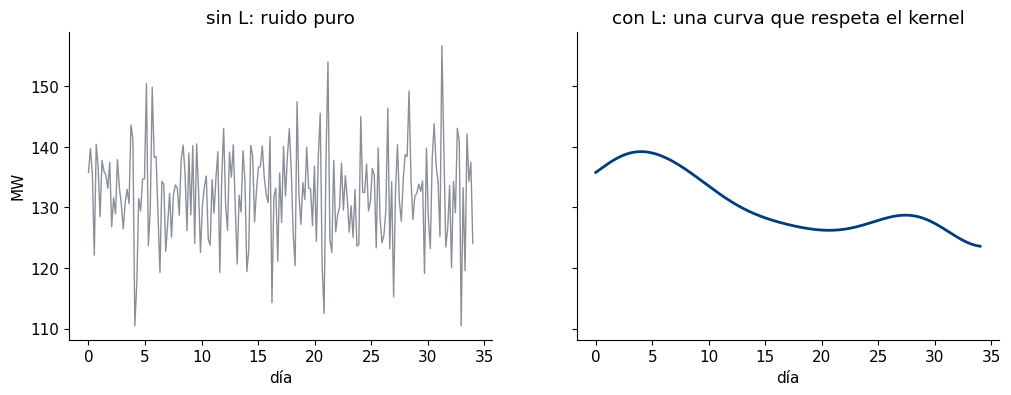

In [8]:
L = np.linalg.cholesky(kxx + 1e-8 * np.eye(n))     # 1e-8 en la diagonal: estabilidad numérica (igual en MATLAB)
ruido = np.random.default_rng(1).normal(size=n)      # n números normales independientes
una_curva = m + L @ ruido

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax[0].plot(x, m + sigma_f * ruido, color=GRIS, lw=1); ax[0].set_title("sin L: ruido puro"); ax[0].set_xlabel("día"); ax[0].set_ylabel("MW")
ax[1].plot(x, una_curva, color=AZUL, lw=2); ax[1].set_title("con L: una curva que respeta el kernel"); ax[1].set_xlabel("día")
plt.show()

### 2c · Sortear 20 curvas

Repetimos con 20 columnas de ruido a la vez. Todas son suaves (por ℓ = 5), suben y bajan alrededor del promedio con amplitud σ_f,
y ninguna pasa por los datos porque **todavía no se los hemos enseñado**.

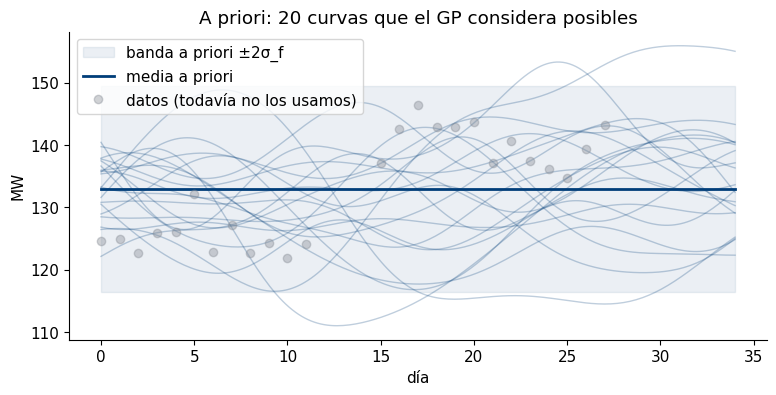

In [9]:
funct = 20                                                                  # cuántas curvas sortear (como en MATLAB)
s = m[:, None] + L @ np.random.default_rng(1).normal(size=(n, funct))       # 20 curvas a priori

plt.plot(x, s, color=AZUL, alpha=0.25, lw=1)
plt.fill_between(x, m - 2*stdpi, m + 2*stdpi, color=AZUL, alpha=0.08, label="banda a priori ±2σ_f")
plt.plot(x, m, color=AZUL, lw=2, label="media a priori")
plt.plot(X, Y, "o", color=GRIS, alpha=0.4, label="datos (todavía no los usamos)")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left"); plt.title("A priori: 20 curvas que el GP considera posibles")
plt.show()

## Paso 3 · El GP después de ver datos, línea por línea

Aquí está el corazón del método. En MATLAB son estas líneas:

```matlab
B1 = phix * mu;                  % media a priori en la malla
B2 = phix * Sigma * phiX';       % kxX : parecido entre malla y datos
B3 = kXX + sigma^2 * eye(N);     % G   : parecido entre datos, más el ruido del medidor
R  = chol(B3);
B4 = Y' - M;                     % datos menos la media
A  = B2 / R;
mpost = B1 + A * (R' \ B4);      % media a posteriori
vpost = kxx - A * A';            % covarianza a posteriori
```

Vamos una por una, y en cada una miramos qué contiene.

### 3a · `B1`: la media a priori en la malla
Lo que creeríamos sin datos: el promedio, en todos los días.

In [10]:
N  = len(X)
B1 = np.full(n, b)                              # (MATLAB: B1 = phix*mu)
print("B1:", B1.shape, " todos valen", round(B1[0], 1))

B1: (200,)  todos valen 132.9


### 3b · `B2`: a qué datos se parece cada día de la malla
Es el kernel entre la malla (200 días) y los datos (25 días). Tomemos un día de la malla, el 30 (ya en la semana futura),
y veamos su fila: se parece mucho a los datos de los días 26 y 27, y nada a los de la primera semana.

B2: (200, 25)


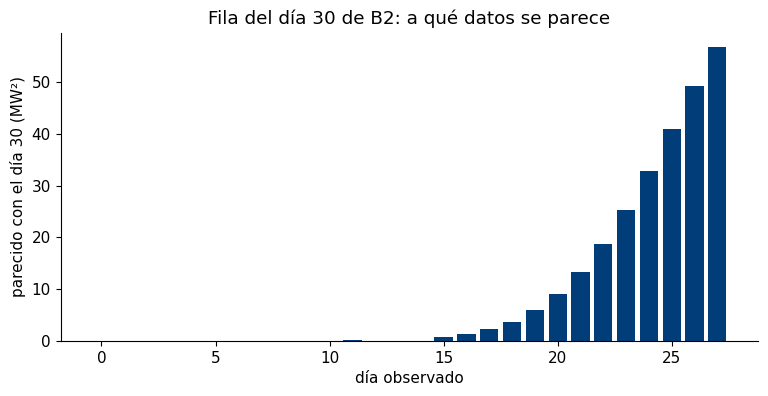

In [11]:
B2 = k(x, X)                                    # kxX: malla vs datos            (MATLAB: B2)
i30 = np.argmin(np.abs(x - 30))                 # índice del día 30 en la malla
print("B2:", B2.shape)

plt.bar(X, B2[i30], width=0.8, color=AZUL)
plt.xlabel("día observado"); plt.ylabel("parecido con el día 30 (MW²)"); plt.title("Fila del día 30 de B2: a qué datos se parece")
plt.show()

### 3c · `B3`: cuánto se parecen los datos entre sí, más el ruido del medidor
Es `kXX` (ya la vimos) con $\sigma_n^2$ sumado en la diagonal. Esa suma dice: "ni siquiera un día consigo mismo es exacto: trae ±2.5 MW de error".
Es lo que impide que la curva pase **exactamente** por cada punto.

In [12]:
B3 = kXX + sigma_n**2 * np.eye(N)               # G: datos vs datos + ruido        (MATLAB: B3)
print("B3:", B3.shape)
print("diagonal de kXX:", round(kXX[0, 0], 1), " → diagonal de B3:", round(B3[0, 0], 1), " (se sumó σ_n² =", sigma_n**2, ")")

B3: (25, 25)
diagonal de kXX: 68.5  → diagonal de B3: 74.8  (se sumó σ_n² = 6.25 )


### 3d · `R`: la raíz de B3
Otra vez Cholesky. Sirve para **resolver** sistemas con B3 sin invertirla (más rápido y más estable). MATLAB `chol()` devuelve la triangular
superior; NumPy la inferior, por eso el `.T`. Comprobamos que `R.T @ R` recupera B3.

In [13]:
R = np.linalg.cholesky(B3).T                    # (MATLAB: R = chol(B3))
print("R:", R.shape, "  R.T @ R == B3:", np.allclose(R.T @ R, B3))

R: (25, 25)   R.T @ R == B3: True


### 3e · `B4`: cuánto se desviaron los datos de lo que creíamos
Los datos menos la media a priori. Positivo = el día estuvo por arriba del promedio.

In [14]:
M  = np.full(N, b)                              # media a priori en los datos       (MATLAB: M = phiX*mu)
B4 = Y - M                                      # (MATLAB: B4)
print("B4 (MW):", np.round(B4[:6], 1), "...")

B4 (MW): [ -8.3  -8.  -10.3  -7.1  -6.9  -0.7] ...


### 3f · `A`: cuánto pesa cada dato para cada día de la malla
Combina B2 (a qué datos se parece cada día) con B3 (cómo se reparten los datos la información). El resultado son **pesos**:
la fila del día 30 dice cuánto influye cada dato en la predicción del día 30. Nótese que los pesos pueden ser negativos: el GP
también "corrige" con datos que se parecen mucho entre sí.

A: (200, 25)


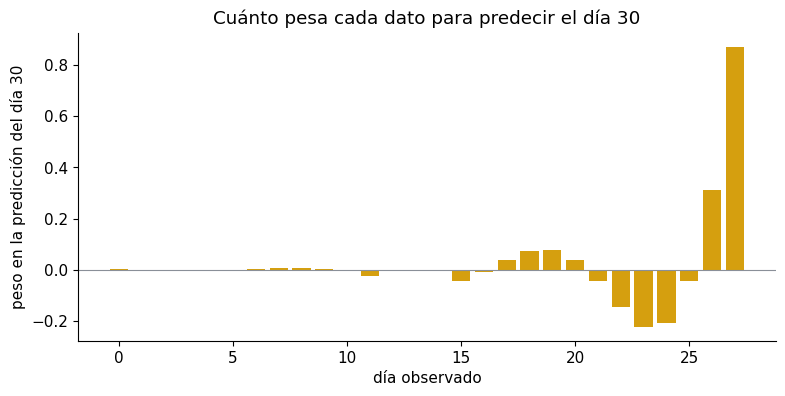

In [15]:
A = np.linalg.solve(R.T, B2.T).T                # A = B2 / R   (resolver, nunca invertir)
pesos_30 = A @ np.linalg.solve(R.T, np.eye(N))  # los pesos efectivos de cada dato (= B2 @ inv(B3))
print("A:", A.shape)

plt.bar(X, pesos_30[i30], width=0.8, color=ORO)
plt.axhline(0, color=GRIS, lw=0.8)
plt.xlabel("día observado"); plt.ylabel("peso en la predicción del día 30"); plt.title("Cuánto pesa cada dato para predecir el día 30")
plt.show()

### 3g · `mpost`: la media a posteriori
Media a priori **más** pesos × desviaciones. Es una curva que pasa cerca de los datos y vuelve al promedio donde no hay datos.

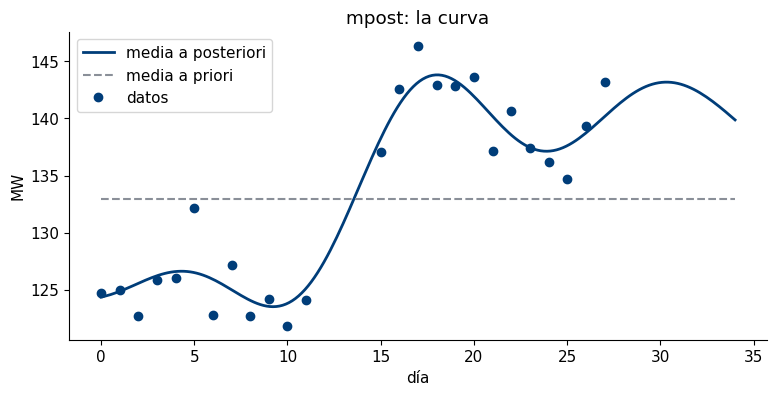

In [16]:
mpost = B1 + A @ np.linalg.solve(R.T, B4)       # media a posteriori
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori")
plt.plot(x, B1, color=GRIS, ls="--", label="media a priori")
plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left"); plt.title("mpost: la curva")
plt.show()

### 3h · `vpost` y `stdpo`: la incertidumbre a posteriori
Incertidumbre a priori **menos** lo que los datos enseñaron. Los datos solo pueden *restar* incertidumbre: `vpost` nunca es mayor que `kxx`.
Su diagonal, con raíz, es la desviación en cada día. Mira dónde es chica (hay datos) y dónde crece (hueco y futuro).

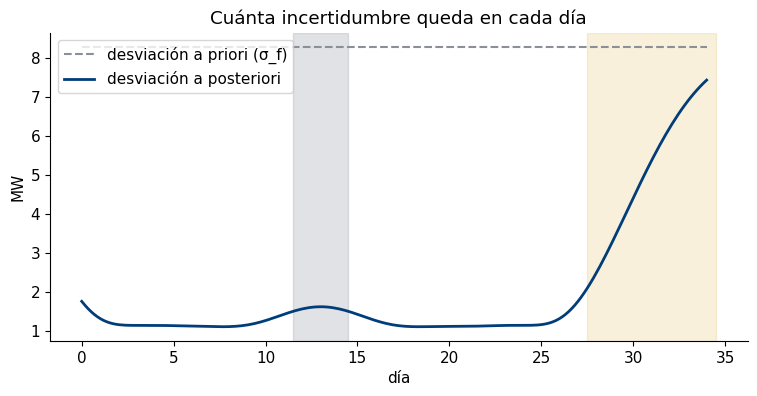

In [17]:
vpost = kxx - A @ A.T                           # covarianza a posteriori
stdpo = np.sqrt(np.diag(vpost))                 # desviación a posteriori en cada día

plt.plot(x, stdpi, color=GRIS, ls="--", label="desviación a priori (σ_f)")
plt.plot(x, stdpo, color=AZUL, lw=2, label="desviación a posteriori")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15); plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25)
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left"); plt.title("Cuánta incertidumbre queda en cada día")
plt.show()

### 3i · `spost`: las 20 curvas, ahora obligadas a pasar cerca de los datos
Mismo truco del Paso 2, pero con `mpost` y `vpost`. Mira tres cosas: la banda angosta donde hay datos, el hueco que se abre y se cierra
(el GP **interpola** con honestidad), y la próxima semana que se abre cada día más (el GP **sabe que no sabe**).

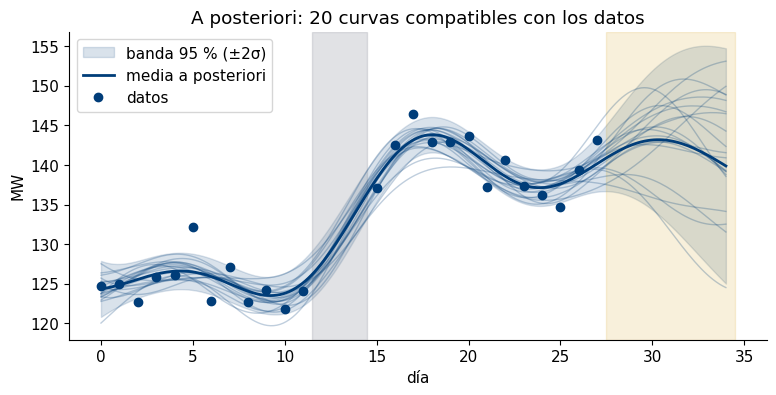

In [18]:
Lp    = np.linalg.cholesky(vpost + 1e-8 * np.eye(n))
spost = mpost[:, None] + Lp @ np.random.default_rng(2).normal(size=(n, funct))

plt.plot(x, spost, color=AZUL, alpha=0.25, lw=1)
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="banda 95 % (±2σ)")
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori")
plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15); plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25)
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left"); plt.title("A posteriori: 20 curvas compatibles con los datos")
plt.show()

## Paso 4 · La respuesta a la pregunta

*¿Cuánta capacidad reservar la próxima semana?* La banda superior del 95 % nos da un número defendible.

In [19]:
futuro = x >= 28
pico_esperado = mpost[futuro].max()
capacidad_95  = (mpost + 2*stdpo)[futuro].max()
print(f"Pico esperado la próxima semana : {pico_esperado:6.1f} MW")
print(f"Capacidad a reservar (95 %)     : {capacidad_95:6.1f} MW")
print(f"Margen que compra la incertidumbre: {capacidad_95 - pico_esperado:4.1f} MW")

Pico esperado la próxima semana :  143.2 MW
Capacidad a reservar (95 %)     :  155.0 MW
Margen que compra la incertidumbre: 11.9 MW


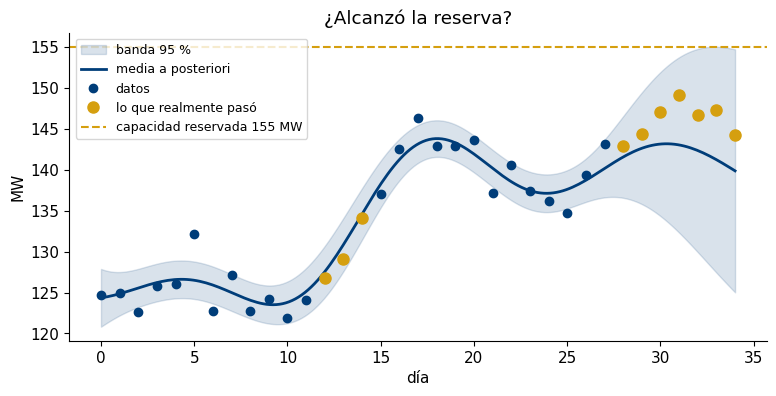

Días ocultos dentro de la banda: 10 de 10   ·   pico real de la semana: 149.1 MW


In [20]:
# Ahora sí: destapamos la semana que estaba escondida
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="banda 95 %")
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori")
plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.plot(t[~observado], y[~observado], "o", color=ORO, markersize=8, label="lo que realmente pasó")
plt.axhline(capacidad_95, color=ORO, ls="--", label=f"capacidad reservada {capacidad_95:.0f} MW")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left", fontsize=9); plt.title("¿Alcanzó la reserva?")
plt.show()

dentro = np.abs(y[~observado] - np.interp(t[~observado], x, mpost)) <= 2*np.interp(t[~observado], x, stdpo)
print(f"Días ocultos dentro de la banda: {dentro.sum()} de {dentro.size}   ·   pico real de la semana: {y[28:].max():.1f} MW")

Compara con tu apuesta: ¿te quedaste corto o te pasaste? Lo que el GP te dio y tu ojo no es el **rango**.

## Paso 5 · Lo mismo con scikit-learn, en 3 líneas

Todo lo anterior ya está programado en `scikit-learn`. Le damos el **mismo kernel** con los **mismos hiperparámetros** y le pedimos
que no los cambie (`optimizer=None`). Dos detalles de traducción: scikit espera los datos como columna (`X[:, None]`), y `alpha` es la
varianza del ruido ($\sigma_n^2$). La media `b` la restamos y sumamos nosotros.

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

kernel = ConstantKernel(sigma_f**2, "fixed") * RBF(length_scale=ell, length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, optimizer=None)
gp.fit(X[:, None], Y - b)
m_skl, s_skl = gp.predict(x[:, None], return_std=True); m_skl = m_skl + b

print(f"Máxima diferencia en la media      : {np.abs(mpost - m_skl).max():.2e} MW")
print(f"Máxima diferencia en la desviación : {np.abs(stdpo - s_skl).max():.2e} MW")

Máxima diferencia en la media      : 2.84e-14 MW
Máxima diferencia en la desviación : 2.75e-14 MW


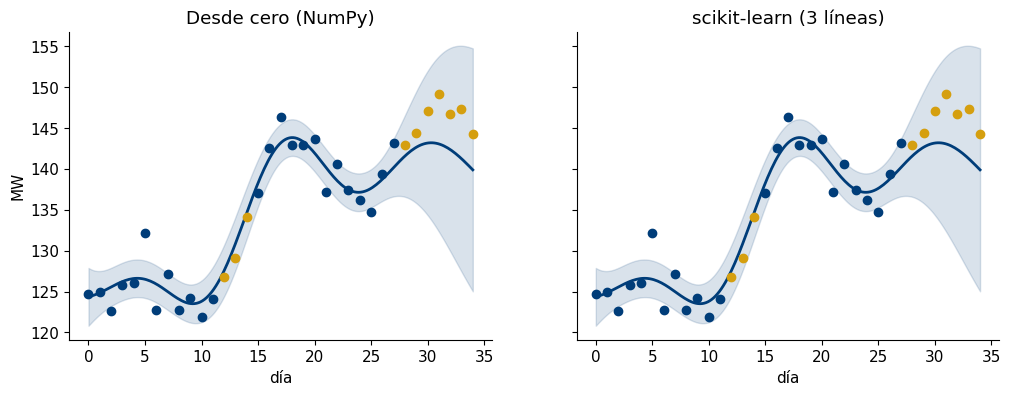

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a_, mm, ss, titulo in [(ax[0], mpost, stdpo, "Desde cero (NumPy)"), (ax[1], m_skl, s_skl, "scikit-learn (3 líneas)")]:
    a_.fill_between(x, mm - 2*ss, mm + 2*ss, color=AZUL, alpha=0.15)
    a_.plot(x, mm, color=AZUL, lw=2); a_.plot(X, Y, "o", color=AZUL)
    a_.plot(t[~observado], y[~observado], "o", color=ORO)
    a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("MW")
plt.show()

Diferencias del orden de $10^{-14}$: es el mismo cálculo. La ventaja de scikit-learn no es que sea "mejor": es que **puede aprender
los hiperparámetros solo** (maximiza la verosimilitud marginal, una medida de qué tan bien explica el modelo los datos).

In [23]:
kernel_libre = ConstantKernel(sigma_f**2) * RBF(length_scale=ell)       # sin "fixed": se pueden ajustar
gp_libre = GaussianProcessRegressor(kernel=kernel_libre, alpha=sigma_n**2, n_restarts_optimizer=5, random_state=0)
gp_libre.fit(X[:, None], Y - b)
m_lib, s_lib = gp_libre.predict(x[:, None], return_std=True); m_lib += b

print("Kernel que aprendió scikit-learn:", gp_libre.kernel_)
print(f"   ℓ a mano = {ell:.1f} días   →   ℓ aprendido = {gp_libre.kernel_.k2.length_scale:.2f} días")
print(f"   Capacidad 95 % a mano = {capacidad_95:.1f} MW   →   con ℓ aprendido = {(m_lib + 2*s_lib)[futuro].max():.1f} MW")

Kernel que aprendió scikit-learn: 8.32**2 * RBF(length_scale=4.15)
   ℓ a mano = 5.0 días   →   ℓ aprendido = 4.15 días
   Capacidad 95 % a mano = 155.0 MW   →   con ℓ aprendido = 154.5 MW


## Paso 6 · Sumar dos kernels

Volvamos a los ingredientes del Paso 0: la serie tiene una **tendencia** suave y un **vaivén que se repite cada 14 días**.
Con un solo kernel RBF, el vaivén se trata como si fuera parte del ruido, y hacia el futuro el GP no sabe que se va a repetir.

Los kernels **se suman**: $k = k_{\text{RBF}} + k_{\text{per}}$. Sumar kernels es sumar hipótesis: "la curva es una parte suave
**más** una parte que se repite". Cada parte tiene sus propios hiperparámetros.

### 6a · El kernel periódico

$$k_{\text{per}}(t,t') = \sigma_p^2 \exp\!\left(-\frac{2\sin^2(\pi\,|t-t'|/P)}{\ell_p^2}\right)$$

- $P$: el periodo. Aquí 14 días (lo sabemos por cómo construimos la serie; en la vida real se ve en los datos o se aprende).
- $\sigma_p$: amplitud del vaivén. Hoy 5 MW.
- $\ell_p$: qué tan "limpia" es la repetición. Hoy 1.

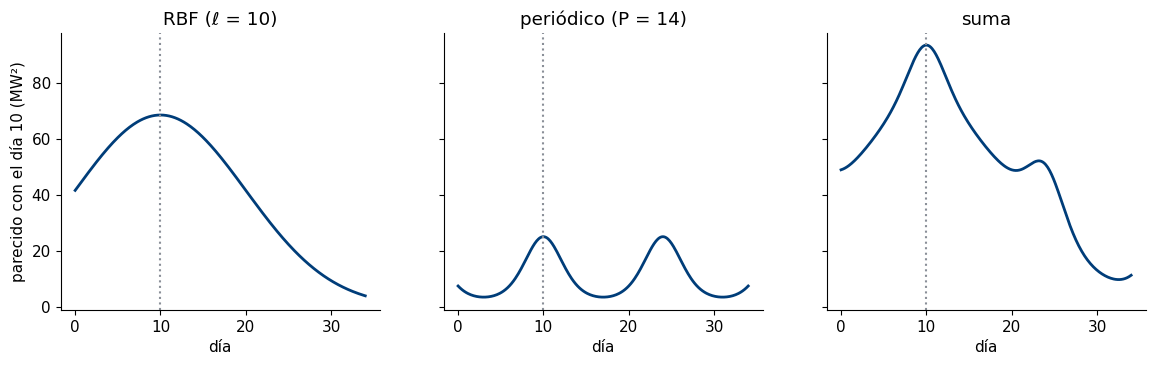

In [24]:
P, sigma_p, ell_p = 14.0, 5.0, 1.0

def k_per(a, c):
    return sigma_p**2 * np.exp(-2 * np.sin(np.pi * np.abs(a[:, None] - c[None, :]) / P)**2 / ell_p**2)

def k_rbf_largo(a, c):
    # el RBF de antes, pero con ℓ = 10: ya no tiene que perseguir el vaivén, solo la tendencia
    return sigma_f**2 * np.exp(-0.5 * (a[:, None] - c[None, :])**2 / 10.0**2)

def k_dos(a, c):
    return k_rbf_largo(a, c) + k_per(a, c)          # ← la suma

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for a_, kk, titulo in [(ax[0], k_rbf_largo, "RBF (ℓ = 10)"), (ax[1], k_per, "periódico (P = 14)"), (ax[2], k_dos, "suma")]:
    a_.plot(d, kk(np.array([10.0]), d)[0], color=AZUL, lw=2); a_.axvline(10, color=GRIS, ls=":"); a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("parecido con el día 10 (MW²)")
plt.show()

Lee la tercera gráfica: con la suma, el día 10 se parece a sus vecinos (por el RBF) **y además** a los días 24 y 38, dos semanas después (por el periódico).

### 6b · Las mismas seis líneas, con el kernel suma

Para no repetir código, empaquetamos el Paso 3 en una función que recibe el kernel. Es exactamente el mismo álgebra.

In [25]:
def posterior(kfun):
    # Las seis líneas del Paso 3, para cualquier kernel kfun(a, c)
    B2 = kfun(x, X)
    B3 = kfun(X, X) + sigma_n**2 * np.eye(N)
    R  = np.linalg.cholesky(B3).T
    A  = np.linalg.solve(R.T, B2.T).T
    m_ = b + A @ np.linalg.solve(R.T, Y - b)
    v_ = kfun(x, x) - A @ A.T
    return m_, np.sqrt(np.clip(np.diag(v_), 0, None))

m_uno, s_uno = posterior(k)          # un kernel (el del Paso 3; debe dar lo mismo que mpost/stdpo)
m_dos, s_dos = posterior(k_dos)      # dos kernels
print("la función reproduce el Paso 3:", np.allclose(m_uno, mpost), np.allclose(s_uno, stdpo))

la función reproduce el Paso 3: True True


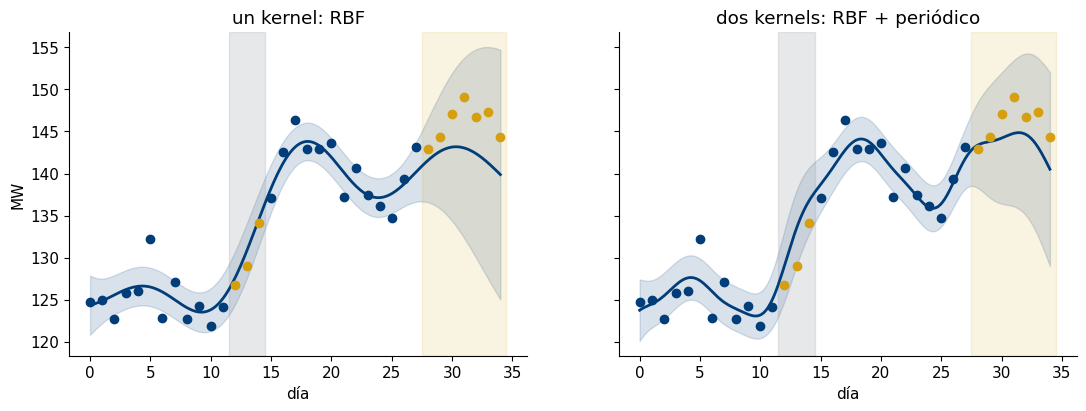

RBF               reserva 95 %  155.0 MW | pico esperado  143.2 | error medio en la semana oculta  4.0 MW | ancho medio de la banda 20.7 MW
RBF + periódico   reserva 95 %  154.3 MW | pico esperado  144.9 | error medio en la semana oculta  2.6 MW | ancho medio de la banda 17.1 MW


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for a_, mm, ss, titulo in [(ax[0], m_uno, s_uno, "un kernel: RBF"), (ax[1], m_dos, s_dos, "dos kernels: RBF + periódico")]:
    a_.fill_between(x, mm - 2*ss, mm + 2*ss, color=AZUL, alpha=0.15)
    a_.plot(x, mm, color=AZUL, lw=2); a_.plot(X, Y, "o", color=AZUL)
    a_.plot(t[~observado], y[~observado], "o", color=ORO)
    a_.axvspan(27.5, 34.5, color=ORO, alpha=0.12); a_.axvspan(11.5, 14.5, color=GRIS, alpha=0.2)
    a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("MW")
plt.show()

real = y[28:]
for nombre, mm, ss in [("RBF", m_uno, s_uno), ("RBF + periódico", m_dos, s_dos)]:
    mf, sf_ = np.interp(t[28:], x, mm), np.interp(t[28:], x, ss)
    print(f"{nombre:<17} reserva 95 % {(mm + 2*ss)[futuro].max():6.1f} MW | pico esperado {mm[futuro].max():6.1f} | "
          f"error medio en la semana oculta {np.abs(real - mf).mean():4.1f} MW | ancho medio de la banda {(4*sf_).mean():4.1f} MW")

Qué cambió con el segundo kernel:

- En el **hueco** y en la **semana futura**, la media ya sigue el vaivén (mira los puntos dorados): el error medio baja.
- La **banda es más angosta** en el futuro: el modelo tiene una hipótesis más para apoyarse. Cuidado: una banda angosta solo es buena si la hipótesis es cierta;
  si la serie no fuera periódica, este kernel nos haría **confiar de más**.
- Los kernels no compiten: el RBF con ℓ = 10 sigue la ola de calor y el periódico el vaivén. Podemos ver cada parte por separado:

### 6c · Ver cada parte de la suma

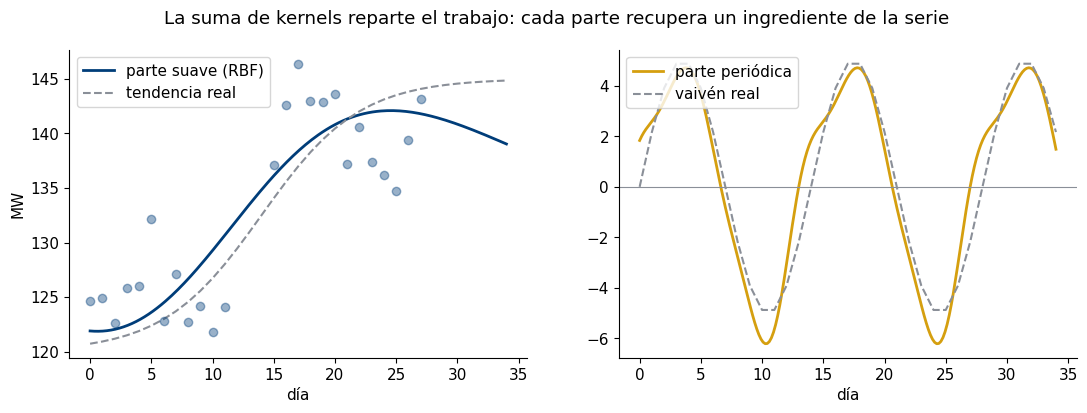

In [27]:
# Con el kernel suma, la media a posteriori se puede repartir entre sus dos partes: cada una usa su propio B2 y los mismos pesos.
B3_dos = k_dos(X, X) + sigma_n**2 * np.eye(N)
pesos  = np.linalg.solve(B3_dos, Y - b)                     # = inv(B3) @ B4, común a las dos partes
parte_suave     = b + k_rbf_largo(x, X) @ pesos
parte_periodica = k_per(x, X) @ pesos

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, parte_suave, color=AZUL, lw=2, label="parte suave (RBF)"); ax[0].plot(t, tendencia, color=GRIS, ls="--", label="tendencia real")
ax[0].plot(X, Y, "o", color=AZUL, alpha=0.4); ax[0].legend(loc="upper left"); ax[0].set_xlabel("día"); ax[0].set_ylabel("MW")
ax[1].plot(x, parte_periodica, color=ORO, lw=2, label="parte periódica"); ax[1].plot(t, vaiven, color=GRIS, ls="--", label="vaivén real")
ax[1].axhline(0, color=GRIS, lw=0.8); ax[1].legend(loc="upper left"); ax[1].set_xlabel("día")
plt.suptitle("La suma de kernels reparte el trabajo: cada parte recupera un ingrediente de la serie")
plt.show()

### 6d · Lo mismo en scikit-learn

Sumar kernels en scikit-learn es literalmente un `+`. Con los mismos hiperparámetros fijos, coincide con nuestra versión.

In [28]:
from sklearn.gaussian_process.kernels import ExpSineSquared

k_skl_dos = (ConstantKernel(sigma_f**2, "fixed") * RBF(10.0, "fixed")
             + ConstantKernel(sigma_p**2, "fixed") * ExpSineSquared(length_scale=ell_p, periodicity=P, length_scale_bounds="fixed", periodicity_bounds="fixed"))
gp_dos = GaussianProcessRegressor(kernel=k_skl_dos, alpha=sigma_n**2, optimizer=None).fit(X[:, None], Y - b)
m_skl_dos, s_skl_dos = gp_dos.predict(x[:, None], return_std=True); m_skl_dos += b
print(f"Diferencia con nuestra versión de dos kernels — media: {np.abs(m_dos - m_skl_dos).max():.2e} MW, desviación: {np.abs(s_dos - s_skl_dos).max():.2e} MW")

Diferencia con nuestra versión de dos kernels — media: 5.68e-14 MW, desviación: 2.15e-14 MW


## Lo que aprendimos

**Un proceso gaussiano es:** un kernel (la hipótesis de parecido) + seis líneas de álgebra que actualizan esa hipótesis con los datos.
Devuelve una curva **y** su margen de error, y el margen es la respuesta a preguntas de planeación ("¿cuánto reservo?").

| | Desde cero | scikit-learn |
|---|---|---|
| Líneas | ~15 | 3 |
| Entiendes qué pasa | sí | solo si hiciste lo anterior |
| Aprende hiperparámetros | no (a mano) | sí |
| Sumar kernels | sumar dos funciones | un `+` |
| Resultado | idéntico | idéntico |

**Tarea** (`03_tarea.ipynb`): la misma ciudad, pero ahora con **ritmo semanal** (los fines de semana baja la demanda). Aplicarás la suma
de kernels con un periodo de 7 días y dejarás que scikit-learn aprenda los hiperparámetros.

---
### Apéndice (opcional): la versión literal del código MATLAB

El código de la presentación no escribe el kernel directo; lo construye con **1000 "campanas"** $\phi$ centradas en una malla,
y define $k = \phi \, \Sigma \, \phi^\top$. Es la *vista de características* del mismo GP. Aquí está traducido línea por línea
para que compruebes que da la misma banda (con una escala de $\ell$ ligeramente distinta, porque sumar campanas ensancha la campana resultante).

Diferencia con la versión directa — media: 0.031 MW, desviación: 0.103 MW


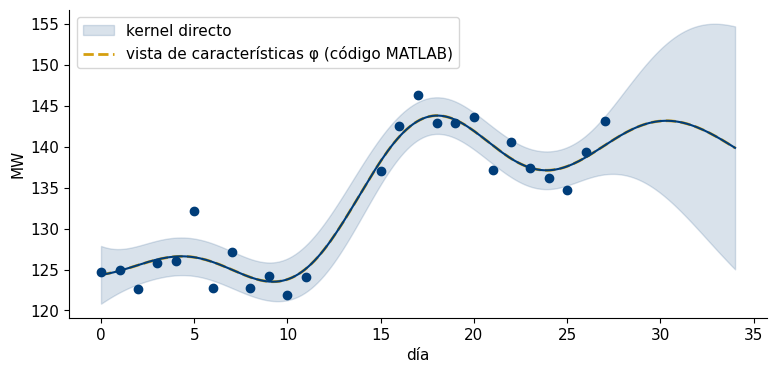

In [29]:
# --- traducción literal de la lámina (vista de características φ) ---
F = 1000
centros = np.linspace(-5, 39, F)
ell_phi = ell / np.sqrt(2)                                          # sumar campanas de ancho ℓ/√2 da un kernel de ancho ℓ
phi = lambda a: np.exp(-0.5 * (a[:, None] - centros[None, :])**2 / ell_phi**2)     # phi = @(a)(exp(-0.5*bsxfun(@minus,a,linspace(...)).^2./ell.^2))
mu = np.zeros(F)                                                    # mu = zeros(F,1)
escala = sigma_f**2 / (phi(np.array([17.0])) @ phi(np.array([17.0])).T)[0, 0]
Sigma = escala * np.eye(F)                                          # Sigma = eye(F)  (escalada para que k(t,t) = σ_f²)

phix = phi(x);  phiX = phi(X)
kxx_phi = phix @ Sigma @ phix.T                                     # kxx = phix*Sigma*phix'
kXX_phi = phiX @ Sigma @ phiX.T                                     # kXX = phiX*Sigma*phiX'
B1_ = phix @ mu + b;  B2_ = phix @ Sigma @ phiX.T;  B3_ = kXX_phi + sigma_n**2 * np.eye(N)
R_  = np.linalg.cholesky(B3_).T;  B4_ = Y - (phiX @ mu + b)
A_  = np.linalg.solve(R_.T, B2_.T).T
mpost_phi = B1_ + A_ @ np.linalg.solve(R_.T, B4_)
stdpo_phi = np.sqrt(np.clip(np.diag(kxx_phi - A_ @ A_.T), 0, None))

print(f"Diferencia con la versión directa — media: {np.abs(mpost_phi - mpost).max():.3f} MW, desviación: {np.abs(stdpo_phi - stdpo).max():.3f} MW")
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="kernel directo")
plt.plot(x, mpost_phi, color=ORO, lw=2, ls="--", label="vista de características φ (código MATLAB)")
plt.plot(x, mpost, color=AZUL); plt.plot(X, Y, "o", color=AZUL)
plt.legend(loc="upper left"); plt.xlabel("día"); plt.ylabel("MW"); plt.show()